<a href="https://colab.research.google.com/github/chipojaya1/LaborIQ-demo/blob/main/LaborIQ_Colab_Demo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LaborIQ Demo (Google Colab launcher)

This notebook runs the LaborIQ FastAPI backend inside Colab and lets you demo it without VS Code or any local setup.

**How to use:** `Runtime > Run all`, or run the cells top to bottom. Steps 1 to 4 are required. Everything after that is demo material.

Note: the OEWS salary data in this demo covers four occupations (Data Scientists, Database Administrators, Database Architects, Data Entry Keyers). Ask about one of those **plus a state** for the best results.

## 1. Get the code from GitHub
Clones your public repo (chipojaya1/LaborIQ-demo). No token needed.

This cell also checks that the app and its data files came through. If the data files are missing from GitHub (GitHub's website refuses files over 25 MB, so the 70 MB skills file often gets left out), it will show an **upload button**: pick your `LaborIQ-demo-main.zip` and it fills in the missing files.

In [1]:
REPO_URL = "https://github.com/chipojaya1/LaborIQ-demo.git"  #@param {type:"string"}

import os, glob, shutil, zipfile
REPO_DIR = "/content/LaborIQ-demo"
NEEDED = ["oews_final.csv", "bls_final.csv", "glassdoor_final.csv",
          "glassdoor_extracted_skills.csv", "custom_tech_skills.json"]

os.chdir("/content")
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    shutil.rmtree(REPO_DIR, ignore_errors=True)
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull --quiet   # grab anything pushed since the last run

# Find the app, even if it sits inside a subfolder of the repo
hits = glob.glob(f"{REPO_DIR}/**/backend/app/main.py", recursive=True)
if not hits:
    print("Top level of the repo:", os.listdir(REPO_DIR) if os.path.exists(REPO_DIR) else "clone failed")
    raise RuntimeError("Could not find backend/app/main.py in the repo. Check that the code was pushed to GitHub.")
APP_ROOT = hits[0][: -len("/backend/app/main.py")]
os.chdir(APP_ROOT)

def is_missing(name):
    path = os.path.join("data", name)
    if not os.path.exists(path):
        return True
    with open(path, "rb") as fh:  # Git LFS leaves a tiny placeholder instead of the real file
        return fh.read(40).startswith(b"version https://git-lfs")

missing = [f for f in NEEDED if is_missing(f)]
if missing:
    print("These data files are not in the GitHub repo:", missing)
    print("Upload your LaborIQ-demo-main.zip to fill them in:")
    from google.colab import files
    for name in files.upload():
        with zipfile.ZipFile(name) as z:
            z.extractall("/content/_laboriq_zip")
    src = [os.path.dirname(p) for p in glob.glob("/content/_laboriq_zip/**/data/oews_final.csv", recursive=True)]
    if not src:
        raise RuntimeError("That zip has no data/ folder in it.")
    os.makedirs("data", exist_ok=True)
    for f in os.listdir(src[0]):
        if is_missing(f):
            shutil.copy(os.path.join(src[0], f), os.path.join("data", f))
    missing = [f for f in NEEDED if is_missing(f)]

print("App folder:", os.getcwd())
print("Data files:", sorted(os.listdir("data")))
print("All data present" if not missing else f"Still missing: {missing}")

Cloning into '/content/LaborIQ-demo'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 34 (delta 3), reused 28 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 2.25 MiB | 3.61 MiB/s, done.
Resolving deltas: 100% (3/3), done.
App folder: /content/LaborIQ-demo
Data files: ['bls_final.csv', 'custom_tech_skills.json', 'glassdoor_extracted_skills.csv', 'glassdoor_final.csv', 'oews_final.csv', 'oews_final_addingcost.csv']
All data present


## 2. Install dependencies
The repo's `requirements.txt` pins `openai==1.8.5`, a version that does not exist on PyPI, so installing from that file fails. This cell installs the packages the app actually uses instead.

In [2]:
!pip install --quiet fastapi "uvicorn[standard]" pandas rapidfuzz python-multipart PyPDF2 python-docx "openai>=1.30,<2" pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 44.0 MB/s eta 0:00:00


## 3. Start the backend
Runs the API in the background on port 8000 and waits until `/health` answers.

In [3]:
import threading, time, requests, uvicorn

BASE = "http://127.0.0.1:8000"

def _alive():
    try:
        return requests.get(f"{BASE}/health", timeout=2).ok
    except Exception:
        return False

if not _alive():
    config = uvicorn.Config("backend.app.main:app", host="0.0.0.0", port=8000, log_level="warning")
    server = uvicorn.Server(config)
    threading.Thread(target=server.run, daemon=True).start()
    for _ in range(60):
        if _alive():
            break
        time.sleep(1)

print("Backend status:", requests.get(f"{BASE}/health").json())

Backend status: {'status': 'ok'}


## 4. Open the interactive API page (Swagger UI)
This gives you a clickable web page for every endpoint, handy for a live demo. Click the link that appears, then open an endpoint, press **Try it out**, and **Execute**.

In [4]:
from google.colab import output
output.serve_kernel_port_as_window(8000, path="/docs")

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

## 5. Chatbot demo
`ask()` sends a question to `/api/chat`, the same endpoint the Figma Make prototype uses.

In [5]:
import pandas as pd
from IPython.display import display, Markdown

def ask(question, mode="market_insights", show_table=True):
    r = requests.post(f"{BASE}/api/chat", json={"question": question, "mode": mode})
    if not r.ok:
        display(Markdown(f"**You:** {question}  \n**LaborIQ:** _(no answer; try naming an occupation and a state)_"))
        return None
    data = r.json()
    display(Markdown(f"**You:** {question}  \n**LaborIQ:** {data['answer']}"))
    states = (data.get("payload") or {}).get("states")
    if show_table and states:
        cols = ["state_name", "average_salary", "median_salary", "total_employment"]
        df = pd.DataFrame(states)
        display(df[[c for c in cols if c in df.columns]].head(5))
    return data

ask("hello", show_table=False)
ask("What is the average salary for data scientist in Texas?")

**You:** hello  
**LaborIQ:** Hi there! How can I help you with your career insights today?

=== MARKET_INSIGHTS DEBUG START ===
raw_metric = average_salary
metric_key = average_salary
csv_column = a_mean
=== MARKET_INSIGHTS DEBUG END ===
Loaded CSV columns: ['location_id', 'state_name', 'area_type', 'state_code', 'industry_group', 'occupation_code', 'occupation', 'total_employment', 'jobs_per_1000', 'hourly_mean', 'average_salary', 'hourly_median', 'median_salary', 'hourly_mean_adjusted', 'average_salary_adjusted', 'a_mean', 'h_mean', 'a_mean_adj', 'h_mean_adj', 'a_median', 'tot_emp']


**You:** What is the average salary for data scientist in Texas?  
**LaborIQ:** The average salary for Data Scientist in Texas is $114,800.

,state_name,average_salary,median_salary,total_employment
0,Washington,162730.0,158760.0,7930
1,California,155450.0,136800.0,36850
2,District Of Columbia,148170.0,137120.0,3580
3,Massachusetts,139670.0,132250.0,9990
4,Maryland,135370.0,124340.0,3400


{'answer': 'The average salary for Data Scientist in Texas is $114,800.',
 'sources': ['OEWS state-level dataset'],
 'payload': {'states': [{'state_name': 'Washington',
    'state_code': 'WA',
    'average_salary': 162730.0,
    'average_salary_adjusted': 149791.3249,
    'hourly_mean': 78.24,
    'hourly_mean_adjusted': 72.01913146,
    'median_salary': 158760.0,
    'total_employment': 7930},
   {'state_name': 'California',
    'state_code': 'CA',
    'average_salary': 155450.0,
    'average_salary_adjusted': 138772.8357,
    'hourly_mean': 74.74,
    'hourly_mean_adjusted': 66.72165803,
    'median_salary': 136800.0,
    'total_employment': 36850},
   {'state_name': 'District Of Columbia',
    'state_code': 'DC',
    'average_salary': 148170.0,
    'average_salary_adjusted': 133446.8131,
    'hourly_mean': 71.24,
    'hourly_mean_adjusted': 64.16110526,
    'median_salary': 137120.0,
    'total_employment': 3580},
   {'state_name': 'Massachusetts',
    'state_code': 'MA',
    'avera

In [6]:
ask("What is the average salary for database administrators in Virginia?")
ask("Total employment for data scientist in Virginia")

=== MARKET_INSIGHTS DEBUG START ===
raw_metric = average_salary
metric_key = average_salary
csv_column = a_mean
=== MARKET_INSIGHTS DEBUG END ===
Loaded CSV columns: ['location_id', 'state_name', 'area_type', 'state_code', 'industry_group', 'occupation_code', 'occupation', 'total_employment', 'jobs_per_1000', 'hourly_mean', 'average_salary', 'hourly_median', 'median_salary', 'hourly_mean_adjusted', 'average_salary_adjusted', 'a_mean', 'h_mean', 'a_mean_adj', 'h_mean_adj', 'a_median', 'tot_emp']


**You:** What is the average salary for database administrators in Virginia?  
**LaborIQ:** The average salary for Database Administrator in Virginia is $113,810.

,state_name,average_salary,median_salary,total_employment
0,New Jersey,126670.0,128970.0,2060
1,Maryland,124430.0,122110.0,2640
2,District Of Columbia,120470.0,128440.0,550
3,California,119060.0,111090.0,8360
4,Kansas,118250.0,112740.0,560


=== MARKET_INSIGHTS DEBUG START ===
raw_metric = total_employment
metric_key = total_employment
csv_column = tot_emp
=== MARKET_INSIGHTS DEBUG END ===
Loaded CSV columns: ['location_id', 'state_name', 'area_type', 'state_code', 'industry_group', 'occupation_code', 'occupation', 'total_employment', 'jobs_per_1000', 'hourly_mean', 'average_salary', 'hourly_median', 'median_salary', 'hourly_mean_adjusted', 'average_salary_adjusted', 'a_mean', 'h_mean', 'a_mean_adj', 'h_mean_adj', 'a_median', 'tot_emp']


**You:** Total employment for data scientist in Virginia  
**LaborIQ:** Estimated employment for Data Scientist in Virginia: 6,200.

,state_name,average_salary,median_salary,total_employment
0,California,155450.0,136800.0,36850
1,Texas,114800.0,106540.0,23420
2,New York,133450.0,125400.0,20070
3,Pennsylvania,107450.0,100320.0,10430
4,North Carolina,118020.0,115380.0,10140


{'answer': 'Estimated employment for Data Scientist in Virginia: 6,200.',
 'sources': ['OEWS state-level dataset'],
 'payload': {'states': [{'state_name': 'California',
    'state_code': 'CA',
    'average_salary': 155450.0,
    'average_salary_adjusted': 138772.8357,
    'hourly_mean': 74.74,
    'hourly_mean_adjusted': 66.72165803,
    'median_salary': 136800.0,
    'total_employment': 36850},
   {'state_name': 'Texas',
    'state_code': 'TX',
    'average_salary': 114800.0,
    'average_salary_adjusted': 117070.4646,
    'hourly_mean': 55.19,
    'hourly_mean_adjusted': 56.28152387,
    'median_salary': 106540.0,
    'total_employment': 23420},
   {'state_name': 'New York',
    'state_code': 'NY',
    'average_salary': 133450.0,
    'average_salary_adjusted': 122583.6913,
    'hourly_mean': 64.16,
    'hourly_mean_adjusted': 58.9357035,
    'median_salary': 125400.0,
    'total_employment': 20070},
   {'state_name': 'Pennsylvania',
    'state_code': 'PA',
    'average_salary': 10745

## 6. Top states for an occupation (`/api/insights`)

=== MARKET_INSIGHTS DEBUG START ===
raw_metric = average_salary
metric_key = average_salary
csv_column = a_mean
=== MARKET_INSIGHTS DEBUG END ===
Loaded CSV columns: ['location_id', 'state_name', 'area_type', 'state_code', 'industry_group', 'occupation_code', 'occupation', 'total_employment', 'jobs_per_1000', 'hourly_mean', 'average_salary', 'hourly_median', 'median_salary', 'hourly_mean_adjusted', 'average_salary_adjusted', 'a_mean', 'h_mean', 'a_mean_adj', 'h_mean_adj', 'a_median', 'tot_emp']


,state_name,average_salary,average_salary_adjusted,total_employment
0,Washington,162730.0,149791.3249,7930
1,California,155450.0,138772.8357,36850
2,District Of Columbia,148170.0,133446.8131,3580
3,Massachusetts,139670.0,129164.7709,9990
4,Maryland,135370.0,128559.6795,3400


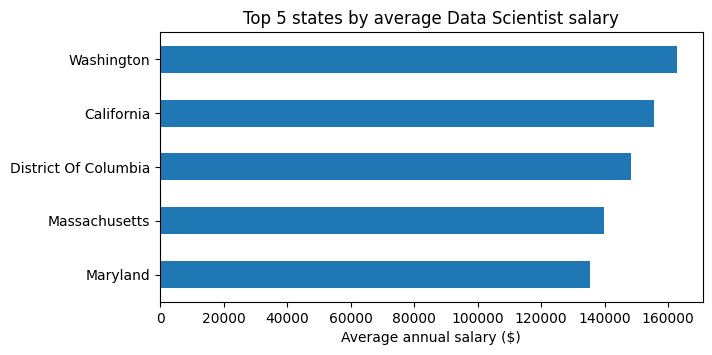

In [7]:
r = requests.post(f"{BASE}/api/insights",
                  json={"occupation": "Data Scientist", "metric": "average_salary", "top_n": 5})
top = pd.DataFrame(r.json()["states"])
ax = top.plot.barh(x="state_name", y="average_salary", legend=False, figsize=(7, 3.5),
                   title="Top 5 states by average Data Scientist salary")
ax.invert_yaxis(); ax.set_xlabel("Average annual salary ($)"); ax.set_ylabel("")
top[["state_name", "average_salary", "average_salary_adjusted", "total_employment"]]

## 7. Skill extraction from a job description (`/api/skills`, runs locally, no API key)

In [8]:
jd = """We are hiring a Data Scientist with strong Python and SQL skills,
experience with TensorFlow, Tableau dashboards, and communicating insights to stakeholders."""
pd.DataFrame(requests.post(f"{BASE}/api/skills", json={"job_description": jd}).json()["skills"])

,skill,score
0,SQL,1.100000
1,Data Science,0.833333
2,Python,0.100000
3,Tableau,0.100000
4,Communication,0.100000


## 8. Macro trend: US unemployment rate (`/api/bls/unemployment_rate`)

Text(0.5, 0, '')

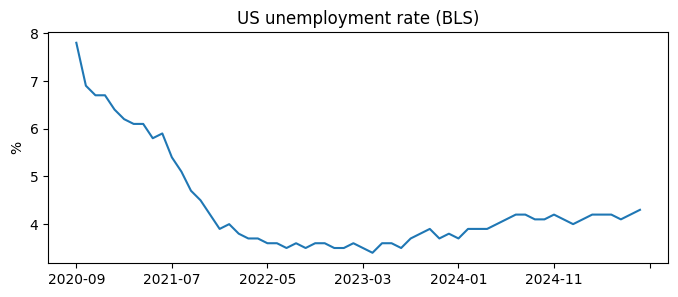

In [9]:
bls = pd.DataFrame(requests.get(f"{BASE}/api/bls/unemployment_rate").json()["data"])
ax = bls.plot(x="date", y="value", legend=False, figsize=(8, 3), title="US unemployment rate (BLS)")
ax.set_ylabel("%"); ax.set_xlabel("")

## 9. (Optional) AI skill analysis with a free Hugging Face token
The AI features (`/api/skill_analysis`, and skill questions in the chat) were written for OpenAI. This cell reroutes them to Hugging Face's OpenAI-compatible endpoint instead, so **no OpenAI key is needed** and no code in the repo changes.

- The cell reads your Hugging Face token from Colab **Secrets**. It finds common names like `HF_TOKEN` automatically; if yours is named differently, type the name into `HF_SECRET_NAME`.
- Make sure the secret's **Notebook access** switch is on.
- The token needs the **Make calls to Inference Providers** permission. If you get a 401 or 403 error, create a new fine-grained token at huggingface.co under **Settings > Access Tokens** with that box ticked.

Free accounts get a small monthly inference credit, which is plenty for a demo. If a model gives an error, try another one from the dropdown.

In [10]:
HF_MODEL = "Qwen/Qwen2.5-7B-Instruct"  #@param ["Qwen/Qwen2.5-7B-Instruct", "meta-llama/Llama-3.1-8B-Instruct", "openai/gpt-oss-20b", "deepseek-ai/DeepSeek-V3-0324"] {allow-input: true}
HF_SECRET_NAME = ""  #@param {type:"string"}
HF_BASE_URL = "https://router.huggingface.co/v1"

import os, getpass
from openai import OpenAI
import backend.app.services.model_skill_analysis as msa

def get_secret(preferred, fallbacks):
    """Read a token from Colab Secrets, trying the name you typed first, then common names."""
    try:
        from google.colab import userdata
    except ImportError:
        return None
    for name in ([preferred] if preferred else []) + fallbacks:
        try:
            value = userdata.get(name)
            if value:
                print(f"Using Colab secret: {name}")
                return value
        except Exception:
            pass
    return None

hf_token = get_secret(HF_SECRET_NAME, ["HF_TOKEN", "HUGGINGFACE_TOKEN", "HUGGING_FACE_TOKEN", "HF_API_KEY", "HUGGINGFACEHUB_API_TOKEN", "hf_token"])
hf_token = hf_token or getpass.getpass("Hugging Face token: ")

class HuggingFaceClient(OpenAI):
    """Same interface as OpenAI(), but sends requests to Hugging Face and swaps in HF_MODEL."""
    def __init__(self, api_key=None, **kwargs):
        super().__init__(api_key=api_key, base_url=HF_BASE_URL, **kwargs)
        original_create = self.chat.completions.create
        def create(*args, **kw):
            kw["model"] = HF_MODEL
            return original_create(*args, **kw)
        self.chat.completions.create = create

msa.OpenAI = HuggingFaceClient          # the app now builds a Hugging Face client
os.environ["OPENAI_API_KEY"] = hf_token  # the app checks this variable before running AI features
print(f"AI features now use {HF_MODEL} on Hugging Face.")

Using Colab secret: HF_TOKEN
AI features now use Qwen/Qwen2.5-7B-Instruct on Hugging Face.


In [11]:
jd = "We need a Data Scientist with Python, SQL, TensorFlow and Tableau experience who can explain results to stakeholders."
r = requests.post(f"{BASE}/api/skill_analysis", data={"job_description": jd})  # this endpoint takes form data
print("Status:", r.status_code)
result = r.json()
insight = result.get("chatbot_insight") or {}
display(Markdown(f"**Summary:** {insight.get('summary', '')}"))
print("Skills found:", result.get("raw_skills"))
print("Recommendations:", insight.get("recommendations"))

Status: 200


**Summary:** 

Skills found: []
Recommendations: []


In [12]:
# The chatbot also routes skill questions to the AI model
ask("What skills do I need for a data analyst job that asks for SQL, Excel and Power BI?", show_table=False)

**You:** What skills do I need for a data analyst job that asks for SQL, Excel and Power BI?  
**LaborIQ:** 

{'answer': '',
 'sources': ['Skill extraction supported by GWU LAiSER Team'],
 'payload': {'raw_skills': [],
  'in_demand_skills': [],
  'categories': {'programming_languages': [],
   'data_management_query_languages': [],
   'cloud_devops_platforms': [],
   'machine_learning_ai_frameworks': [],
   'data_visualization_bi_tools': [],
   'version_control_collaboration_tools': []},
  'chatbot_insight': {'summary': '', 'top_skills': [], 'recommendations': []}}}

## 10. (Optional) Public link for the Figma Make prototype
Only needed if you want to demo the Figma Make front end. ngrok gives the Colab backend a public URL. You need a free ngrok authtoken from dashboard.ngrok.com.

In Figma Make, point the HTTP Request data source at `<public URL>/api/chat`. Keep this notebook running during the demo; the URL changes every time you restart.

In [13]:
from pyngrok import ngrok
import getpass
ngrok.set_auth_token(getpass.getpass("ngrok authtoken: "))
public_url = ngrok.connect(8000, "http").public_url
print("Public URL:     ", public_url)
print("Figma chat URL: ", public_url + "/api/chat")
print("Swagger docs:   ", public_url + "/docs")

KeyboardInterrupt: Interrupted by user